In [1]:
# creating own gradient glass

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_regression

In [4]:
X, y = make_regression(n_samples = 1000, n_features= 1, n_informative= 1, n_targets= 1, noise = 20, random_state= 42)

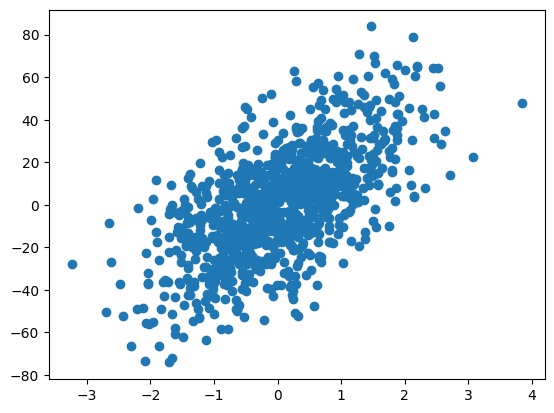

In [5]:
plt.scatter(X, y)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [8]:
class GDR:

  def __init__(self, slope, intercept, learning_rate, epochs):
    self.slope = slope
    self.intercept = intercept
    self.learning_rate = learning_rate
    self.epochs = epochs

  def fit(self, X_train, y_train):
    for i in range(self.epochs):
      y_pred = self.slope * X_train.ravel() + self.intercept

      intercept_diff = -2 * np.mean(y_train - y_pred)
      self.intercept = self.intercept - (self.learning_rate * intercept_diff)

      slope_diff = - 2 * np.mean(X_train.ravel() * (y_train - y_pred))
      self.slope = self.slope - (self.learning_rate * slope_diff)
    return self.slope, self.intercept

  def predict(self, X_test):
    return (self.slope * X_test + self.intercept)

In [31]:
gd = GDR(10, 1, 0.0001, 100000)

In [32]:
gd.fit(X_train, y_train)

(np.float64(9.98304307495332), np.float64(-0.07975475422666056))

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

In [14]:
lr.coef_

array([16.68480472])

In [16]:
lr.intercept_

np.float64(-0.18500205394225427)